# Ejercicio 6

Utilizando el dataset `calidad_producto.csv`, que contiene dos variables registradas en el área de control de calidad de una industria:

- `desviacion_largo`: desviación del largo del producto respecto a un valor estándar o deseado.

- `indice_calidad_producto`: índice o puntuación que se construye a partir de una serie de aspectos relacionados a la calidad general del producto.

1. Calcule los coeficientes de correlación de Pearson y Spearman entre ambas variables. Interprete los valores obtenidos en relación al tipo de información que le brinda cada uno acerca del grado de asociación entre las variables.

2. Construya un gráfico que le permita visualizar la relación general que existe entre las variables analizadas. ¿Qué observa?

3. Calcule nuevamente ambos coeficientes sin tomar en cuenta los registros que incluyan observaciones potencialmente atípicas. ¿Cómo resultan los valores obtenidos en comparación con los calculados en el ítem 1?

4. En función de las características de la relación entre ambas variables que se observan gráficamente, ¿cuál de las dos métricas informaría para describir en forma cuantitativa el grado de asociación entre ellas?

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

In [9]:
df = pd.read_csv('../datasets/calidad_producto.csv', sep=';')
df.head()

,desviacion_largo,indice_calidad_producto
0,-1.090,-0.744
1,0.997,0.720
2,-0.579,-0.548
3,1.270,0.935
4,1.490,0.942


## Item 1

Calcule los coeficientes de correlación de Pearson y Spearman entre ambas variables. Interprete los valores obtenidos en relación al tipo de información que le brinda cada uno acerca del grado de asociación entre las variables.

In [12]:
pearson = df["desviacion_largo"].corr(df["indice_calidad_producto"], method="pearson")
spearman = df["desviacion_largo"].corr(df["indice_calidad_producto"], method="spearman")

print('pearson: =', round(pearson,2),', spearman =', round(spearman,2))

pearson: = 0.56 , spearman = 0.94


## Item 2

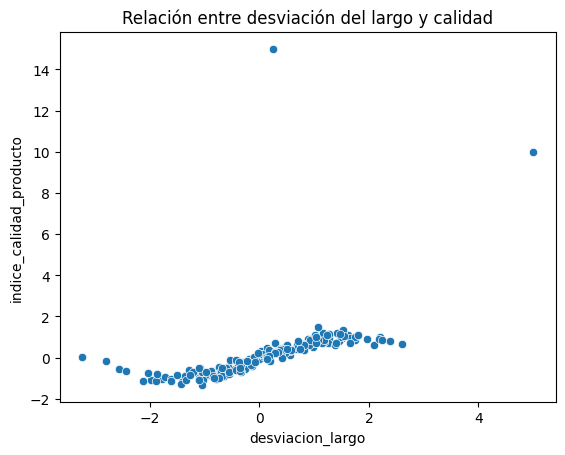

In [13]:
sns.scatterplot(x = "desviacion_largo",
                y = "indice_calidad_producto",
                data = df)

plt.title("Relación entre desviación del largo y calidad")
plt.show()

El gráfico de dispersión muestra una relación positiva entre la desviación del largo y el índice de calidad del producto. En general, se observa una tendencia aproximadamente lineal creciente, lo que indica que a medida que aumenta la desviación, también lo hace el índice de calidad.

Sin embargo, se identifican algunas observaciones atípicas alejadas del patrón general, las cuales podrían influir significativamente en el análisis de correlación.

## Item 3

Calcule nuevamente ambos coeficientes sin tomar en cuenta los registros que incluyan observaciones potencialmente atípicas. ¿Cómo resultan los valores obtenidos en comparación con los calculados en el ítem 1?

In [15]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
RI = Q3 - Q1

df_sin_outliers = df[~((df < (Q1 - 1.5 * RI)) | (df > (Q3 + 1.5 * RI))).any(axis=1)]

In [17]:
pearson2 = df_sin_outliers["desviacion_largo"].corr(df_sin_outliers["indice_calidad_producto"], method="pearson")
spearman2 = df_sin_outliers["desviacion_largo"].corr(df_sin_outliers["indice_calidad_producto"], method="spearman")

print('pearson: =', round(pearson2,2),', spearman =', round(spearman2,2))

pearson: = 0.9 , spearman = 0.95


Al eliminar las observaciones atípicas, se observa que los coeficientes de correlación aumentan, lo que indica que los valores extremos tenían un impacto significativo sobre la estimación de la relación entre las variables.

## Item 4

En función de las características de la relación entre ambas variables que se observan gráficamente, ¿cuál de las dos métricas informaría para describir en forma cuantitativa el grado de asociación entre ellas?

Dado que la relación entre las variables presenta una tendencia aproximadamente lineal pero se encuentra afectada por la presencia de valores atípicos, resulta más adecuado utilizar el coeficiente de Spearman, ya que es más robusto frente a este tipo de observaciones y permite capturar adecuadamente la relación monótona entre las variables.